In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

Plot saved to ../plots/my_football_field.png


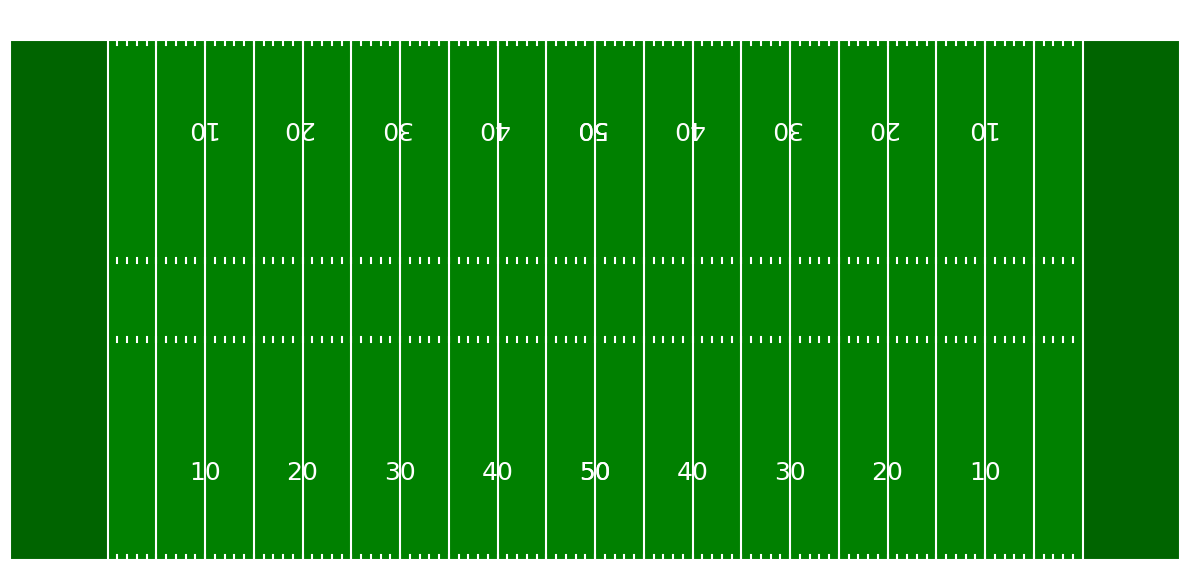

In [2]:
def plot_football_field(endzone_color='darkgreen', line_color='white', hash_color='white', number_color='white', title='American Football Field', save_path=None):
    """
    Plots a regulation American football field using matplotlib.

    Args:
        endzone_color (str): The color for the end zones.
        line_color (str): The color for the main field lines (sidelines, yard lines).
        hash_color (str): The color for the hash marks.
        number_color (str): The color for the yard line numbers.
        title (str): The title of the plot.
        save_path (str, optional): The path to save the plot as a PNG image.
                                   If None, the plot is displayed. Defaults to None.
    """
    # Define field dimensions in yards
    field_length = 120  # Total length including end zones
    field_width = 53.33  # 53 and 1/3 yards

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_facecolor('green')
    ax.set_xlim(0, field_length)
    ax.set_ylim(0, field_width)

    # Draw end zones
    ax.axvspan(0, 10, color=endzone_color, zorder=0)
    ax.axvspan(110, 120, color=endzone_color, zorder=0)
    
    # Draw sidelines and end lines
    ax.plot([0, field_length], [0, 0], color=line_color)  # Bottom sideline
    ax.plot([0, field_length], [field_width, field_width], color=line_color)  # Top sideline
    ax.plot([0, 0], [0, field_width], color=line_color)  # Left end line
    ax.plot([field_length, field_length], [0, field_width], color=line_color)  # Right end line
    
    # Draw yard lines (from 10 to 110)
    for x in range(10, 111, 5):
        ax.plot([x, x], [0, field_width], color=line_color)

    # Draw the 50-yard line with a different style
    # ax.plot([60, 60], [0, field_width], color=line_color, linestyle='--', linewidth=2)

    # Add yardage numbers
    for i in range(10, 60, 10):
        ax.text(10 + i -0.5, field_width - 9, str(i), ha='center', va='center', fontsize=18, color=number_color, rotation=180)
        ax.text(10 + i, 9, str(i), ha='center', va='center', fontsize=18, color=number_color)
        ax.text(110 - i -0.5, field_width - 9, str(i), ha='center', va='center', fontsize=18, color=number_color, rotation=180)
        ax.text(110 - i, 9, str(i), ha='center', va='center', fontsize=18, color=number_color)

    # Add small hash marks
    for x in np.arange(11, 110, 1):
        ax.plot([x, x], [0, 0.5], color=hash_color)  # Bottom
        ax.plot([x, x], [field_width - 0.5, field_width], color=hash_color)  # Top
        ax.plot([x, x], [23.33 - 1, 23.33 - 0.5], color=hash_color)  # Left hash
        ax.plot([x, x], [field_width - 23.33 + 0.5, field_width - 23.33 + 1], color=hash_color) # Right hash

    # Remove ticks and spines
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Set title and aspect ratio
    ax.set_title(title, fontsize=20, color='white')
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()

    # Save or show the plot based on the save_path argument
    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

# Example usage:
if __name__ == '__main__':
    # This will display the plot
    # plot_football_field()

    # This will save the plot to a file
    plot_football_field(save_path='../plots/my_football_field.png')

In [3]:
from ultralytics import YOLO

model = YOLO("yolov9c.pt")

In [5]:
results = model.predict(
    source="../film/2025090400-141-2272139-Sideline_2.mp4",
    # device="mps", 
    tracker="bytetrack.yaml",
    workers=3,
    conf=0.5,
    save=True, 
)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/240) /Users/colinwelsh/Documents/dev/football/python/../film/2025090400-141-2272139-Sideline_2.mp4: 384x640 17 persons, 430.5ms
video 1/1 (frame 2/240) /Users/colinwelsh/Documents/dev/football/python/../film/2025090400-141-2272139-Sideline_2.mp4: 384x640 16 persons, 459.5ms
video 1/1 (frame 3/240) /Users/colinwelsh/Documents/dev/football/python/../film/2025090400-141-2272139-Sideline_2.mp4: 384x640 16 persons, 450.4ms
video 1/1 (fram

In [7]:
for result in results:
    if result.boxes.id is not None:
        # Loop through each tracked object
        for box, track_id in zip(result.boxes.xyxy, result.boxes.id):
            x1, y1, x2, y2 = box
            class_name = model.names[int(result.boxes.cls)]
            
            # Print the tracking ID and other info
            print(f"Track ID: {track_id}, Object: {class_name}, BBox: [{x1}, {y1}, {x2}, {y2}]")

In [6]:
# Define the input and output file paths
input_file = "../film/2025090400-141-2272139-Sideline.mp4"
output_file = "../film/2025090400-141-2272139-Sideline_3.mp4"

# Open the video file
cap = cv2.VideoCapture(input_file)

# Set your desired start and end frames
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
start_frame = total_frames // 2
end_frame = ((total_frames - start_frame) // 2) + 120

if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Set the video position to the start frame
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

# Define the codec and create the VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4 files
out = cv2.VideoWriter(output_file, fourcc, fps, (width, height))

while cap.isOpened():
    # Read the next frame
    ret, frame = cap.read()
    
    # Break the loop if the frame is not read or if we reach the end frame
    if not ret or cap.get(cv2.CAP_PROP_POS_FRAMES) > end_frame:
        break
        
    # Write the frame to the output video
    out.write(frame)

# Release the video objects and close all windows
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Video segment from frame {start_frame} to {end_frame} saved to {output_file}.")

Video segment from frame 480 to 360 saved to ../film/2025090400-141-2272139-Sideline_3.mp4.
